# OCO-2 CO2 Data Exploration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from load_co2 import load_co2
import sys
sys.path.append('..')
from efgpnd import EFGPND
from torch.optim import Adam
import torch


In [2]:
# Load a 100k subsample
# x, meas = load_co2()
x, meas = load_co2(n_sub=100_000)
# print(f"x shape: {x.shape}")       # (2, 100000) — row 0 = lon, row 1 = lat
print(f"meas shape: {meas.shape}") # (100000,)
print(f"CO2 range: {meas.min():.1f} – {meas.max():.1f} ppm")
d,n = x.shape

meas shape: (100000,)
CO2 range: 385.2 – 406.8 ppm


In [3]:
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# fig = plt.figure(figsize=(14, 6))
# ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

# ax.set_global()
# ax.add_feature(cfeature.LAND, facecolor="0.92", edgecolor="none")
# ax.add_feature(cfeature.OCEAN, facecolor="0.97")
# ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
# ax.add_feature(cfeature.BORDERS, linewidth=0.2, linestyle="--")

# # Sort so extreme values render on top
# order = np.argsort(meas)
# lon, lat, co2 = x[0, order], x[1, order], meas[order]

# sc = ax.scatter(
#     lon, lat, c=co2, s=1.5, alpha=0.6,
#     cmap="RdYlGn_r", vmin=392, vmax=408,
#     transform=ccrs.PlateCarree(),
#     linewidths=0, rasterized=True,
# )
# ax.set_title("OCO-2 CO2 concentration (ppm)")
# plt.colorbar(sc, ax=ax, label="CO2 (ppm)", orientation="horizontal", pad=0.05, shrink=0.7)
# plt.tight_layout()

In [4]:
y = torch.tensor(meas)
x = torch.tensor(x).T  # (N, 2) — EFGPND expects (N, d)

In [5]:
# Normalize inputs to [0, 1] and standardize outputs to zero mean, unit variance
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f"x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}")
print(f"y mean={y.mean():.4f}, std={y.std():.4f}")

x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=-0.0000, std=1.0000


In [6]:
x.shape

torch.Size([100000, 2])

In [7]:
d= 2 
EPSILON = 1e-4 # bound on kernel error 
kernel_type = 'SquaredExponential'
# kernel_type = 'Matern32'

cg_tol = 1e-5

In [ ]:
max_iters = 50
J = 1

# Initialize training log
training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
}

model = EFGPND(x, y, kernel=kernel_type, eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.1)

for it in range(max_iters):
    optimizer.zero_grad()
    if it > max_iters*0.8:
        model.compute_gradients(trace_samples=J,cg_tol=cg_tol)
    else:
        model.compute_gradients(trace_samples=J,cg_tol=cg_tol)

    optimizer.step() 


    # logging 
    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)

    if it % 10 == 0:
        print(f"[ε={EPSILON} | J={J}] iter {it:>3}  "
              f"ℓ={lengthscale:.4g}  "
              f"σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}")

print(f'Final hyperparams: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}')


[ε=0.0001 | J=1] iter   0  ℓ=0.2038  σ_f²=1.105  σ_n²=0.221
[ε=0.0001 | J=1] iter  10  ℓ=0.07453  σ_f²=3.016  σ_n²=0.1766
[ε=0.0001 | J=1] iter  20  ℓ=0.02746  σ_f²=7.571  σ_n²=0.157
[ε=0.0001 | J=1] iter  30  ℓ=0.009143  σ_f²=11.85  σ_n²=0.08563


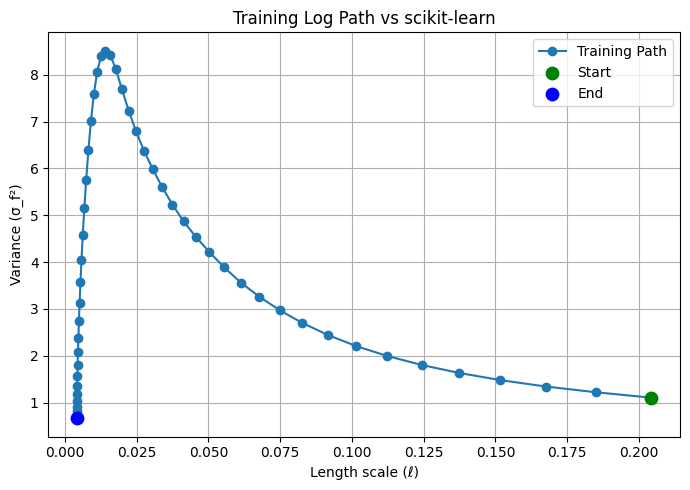

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays for plotting
lengthscale_log = training_log['lengthscale']
variance_log = training_log['variance']

plt.figure(figsize=(7, 5))
plt.plot(lengthscale_log, variance_log, marker='o', label='Training Path', color='C0')
plt.scatter(lengthscale_log[0], variance_log[0], color='green', s=80, label='Start', zorder=5)
plt.scatter(lengthscale_log[-1], variance_log[-1], color='blue', s=80, label='End', zorder=5)

# # Plot scikit-learn learned values
# # if scikit_length_scale is not None:
# # plt.scatter([scikit_length_scale], [scikit_variance], color='red', s=100, marker='*', label='scikit-learn', zorder=10)
# plt.scatter(true_length_scale, true_variance, color='red', s=100, marker='*', label='true', zorder=10)

plt.xlabel('Length scale (ℓ)')
plt.ylabel('Variance (σ_f²)')
plt.title('Training Log Path vs scikit-learn')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Create a prediction grid in normalized [0,1] space
grid_res = 200
lon_grid = torch.linspace(0, 1, grid_res, dtype=x.dtype)
lat_grid = torch.linspace(0, 1, grid_res, dtype=x.dtype)
LON_norm, LAT_norm = torch.meshgrid(lon_grid, lat_grid, indexing='ij')
x_new = torch.stack([LON_norm.flatten(), LAT_norm.flatten()], dim=1)  # (grid_res^2, 2)

# Predict posterior mean on the grid (in normalized y space)
mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0]

# Inverse transforms: map back to original lon/lat and CO2 ppm
mean_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(grid_res, grid_res)
lon_np = (LON_norm.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item())
lat_np = (LAT_norm.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item())

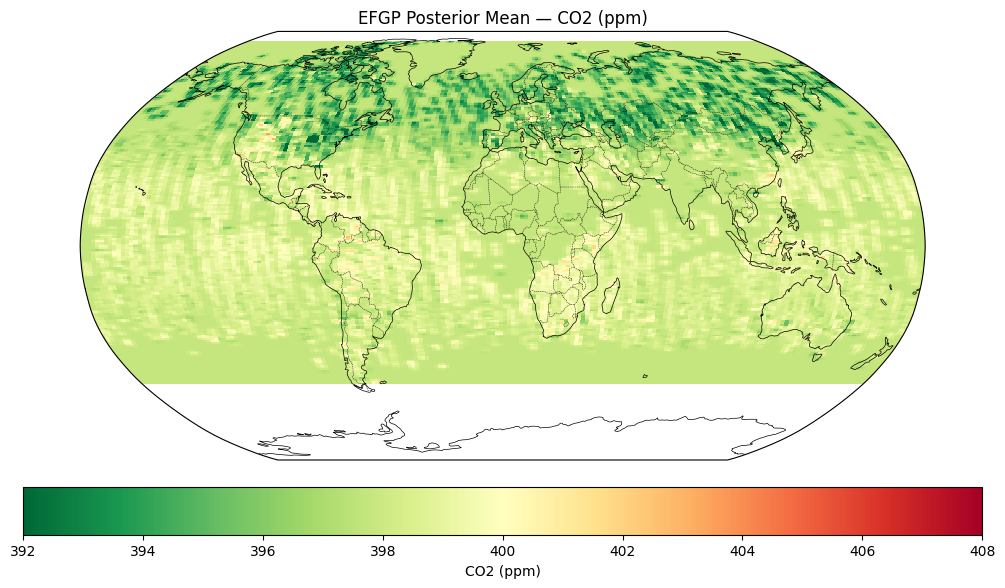

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle="--")

# Plot posterior mean as filled contour on the map
pcm = ax.pcolormesh(
    lon_np, lat_np, mean_grid,
    cmap="RdYlGn_r", vmin=392, vmax=408,
    transform=ccrs.PlateCarree(),
    shading="auto", rasterized=True,
)
ax.set_title("EFGP Posterior Mean — CO2 (ppm)")
plt.colorbar(pcm, ax=ax, label="CO2 (ppm)", orientation="horizontal", pad=0.05, shrink=0.7)
plt.tight_layout()

NameError: name 'scikit_length_scale' is not defined

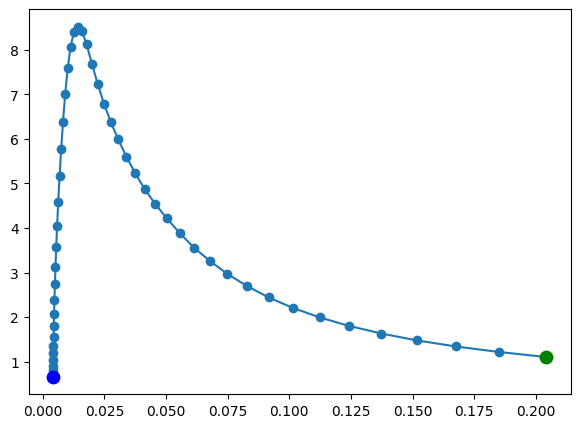

In [ ]:
n,d = x.shape
if n<2000:
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import Matern,RBF,WhiteKernel, ConstantKernel

    # Assume x, y are already defined as numpy arrays of shape (n_samples, n_features) and (n_samples,)
    # Use Matern 3/2 kernel with automatic hyperparameter optimization, including noise variance
    if kernel_type == "Matern32":
        kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level_bounds=(1e-5, 1e1))
    else:
        kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level_bounds=(1e-5, 1e1))

    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=False)
    gp.fit(x, y)

    print("Learned kernel:", gp.kernel_)
    print("Kernel hyperparameters:", gp.kernel_.get_params())
    # Extract the learned variance (signal variance), length scale, and noise variance from the fitted kernel
    # For the kernel: ConstantKernel * Matern + WhiteKernel
    # The signal variance is the value of the ConstantKernel, the length scale is from the Matern kernel,
    # and the noise variance is from the WhiteKernel

    learned_kernel = gp.kernel_

    # Extract variance (ConstantKernel's constant_value), length scale, and noise variance
    if hasattr(learned_kernel, 'k1') and hasattr(learned_kernel.k1, 'k1'):
        scikit_variance = learned_kernel.k1.k1.constant_value
        scikit_length_scale = learned_kernel.k1.k2.length_scale
        scikit_noise_variance = learned_kernel.k2.noise_level
    else:
        # fallback for other kernel structures
        scikit_variance = learned_kernel.k1.constant_value
        scikit_length_scale = learned_kernel.k2.length_scale
        scikit_noise_variance = learned_kernel.k2.noise_level

    print("Learned variance (signal variance):", float(scikit_variance))
    print("Learned length scale:", float(scikit_length_scale))
    print("Learned noise variance:", float(scikit_noise_variance))
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays for plotting
lengthscale_log = training_log['lengthscale']
variance_log = training_log['variance']

plt.figure(figsize=(7, 5))
plt.plot(lengthscale_log, variance_log, marker='o', label='Training Path', color='C0')
plt.scatter(lengthscale_log[0], variance_log[0], color='green', s=80, label='Start', zorder=5)
plt.scatter(lengthscale_log[-1], variance_log[-1], color='blue', s=80, label='End', zorder=5)

# # Plot scikit-learn learned values
# # if scikit_length_scale is not None:
plt.scatter([scikit_length_scale], [scikit_variance], color='red', s=100, marker='*', label='scikit-learn', zorder=10)
# plt.scatter(true_length_scale, true_variance, color='red', s=100, marker='*', label='true', zorder=10)

plt.xlabel('Length scale (ℓ)')
plt.ylabel('Variance (σ_f²)')
plt.title('Training Log Path vs scikit-learn')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


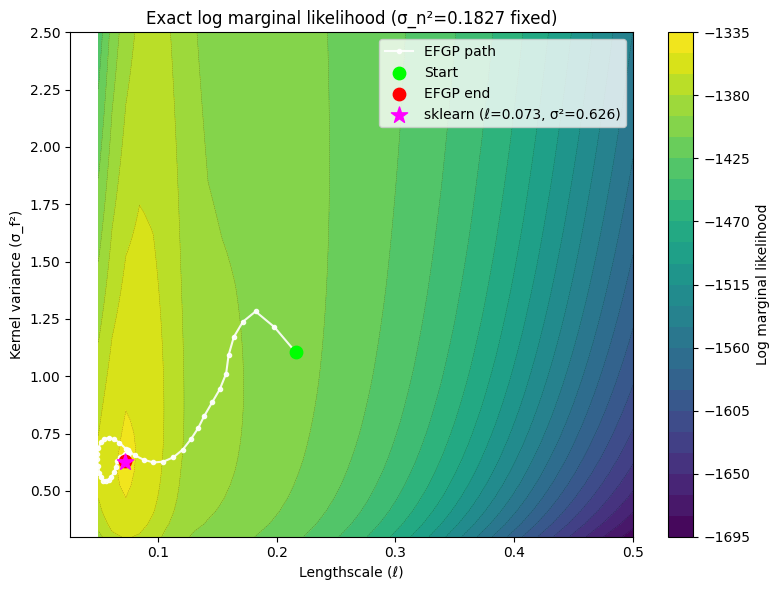

In [ ]:
if n<2000:
    # Ground-truth log marginal likelihood contours (exact Cholesky, feasible for small N)
    from kernels.squared_exponential import SquaredExponential
    from kernels.kernel_params import GPParams

    # Grid over lengthscale and variance
    n_ls, n_var = 40, 40
    ls_range = np.linspace(0.05, 0.5, n_ls)
    var_range = np.linspace(0.3, 2.5, n_var)
    LS, VAR = np.meshgrid(ls_range, var_range, indexing='ij')
    loglik = np.full_like(LS, np.nan)

    # Use sklearn's noise variance so the contours are comparable
    sig2_fixed = scikit_noise_variance
    sig2_fixed = model._gp_params.sig2.item()

    # Evaluate exact log marginal likelihood at each grid point
    k_eval = SquaredExponential(dimension=2)
    gp_eval = GPParams(kernel=k_eval, init_sig2=sig2_fixed)

    for i in range(n_ls):
        for j in range(n_var):
            k_eval.set_hyper('lengthscale', ls_range[i])
            k_eval.set_hyper('variance', var_range[j])
            loglik[i, j] = k_eval.log_marginal(x, y, sig2_fixed)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    levels = 30
    cf = ax.contourf(LS, VAR, loglik, levels=levels, cmap='viridis')
    ax.contour(LS, VAR, loglik, levels=levels, colors='k', linewidths=0.3, alpha=0.4)
    plt.colorbar(cf, ax=ax, label='Log marginal likelihood')

    # Overlay optimization path
    ax.plot(lengthscale_log, variance_log, 'w-o', markersize=3, linewidth=1.5, alpha=0.9, label='EFGP path')
    ax.scatter(lengthscale_log[0], variance_log[0], color='lime', s=80, zorder=5, label='Start')
    ax.scatter(lengthscale_log[-1], variance_log[-1], color='red', s=80, zorder=5, label='EFGP end')

    # Overlay sklearn optimum
    ax.scatter(scikit_length_scale, scikit_variance, color='magenta', s=150, marker='*', 
            zorder=6, label=f'sklearn (ℓ={scikit_length_scale:.3f}, σ²={scikit_variance:.3f})')

    ax.set_xlabel('Lengthscale (ℓ)')
    ax.set_ylabel('Kernel variance (σ_f²)')
    ax.set_title(f'Exact log marginal likelihood (σ_n²={sig2_fixed:.4f} fixed)')
    ax.legend()
    plt.tight_layout()
    plt.show()